In [21]:
import numpy as np
import matplotlib.pyplot as plt

shape of A:  (8, 3)
shape of S:  (3, 10000)
shape of received signal: (8, 10000)


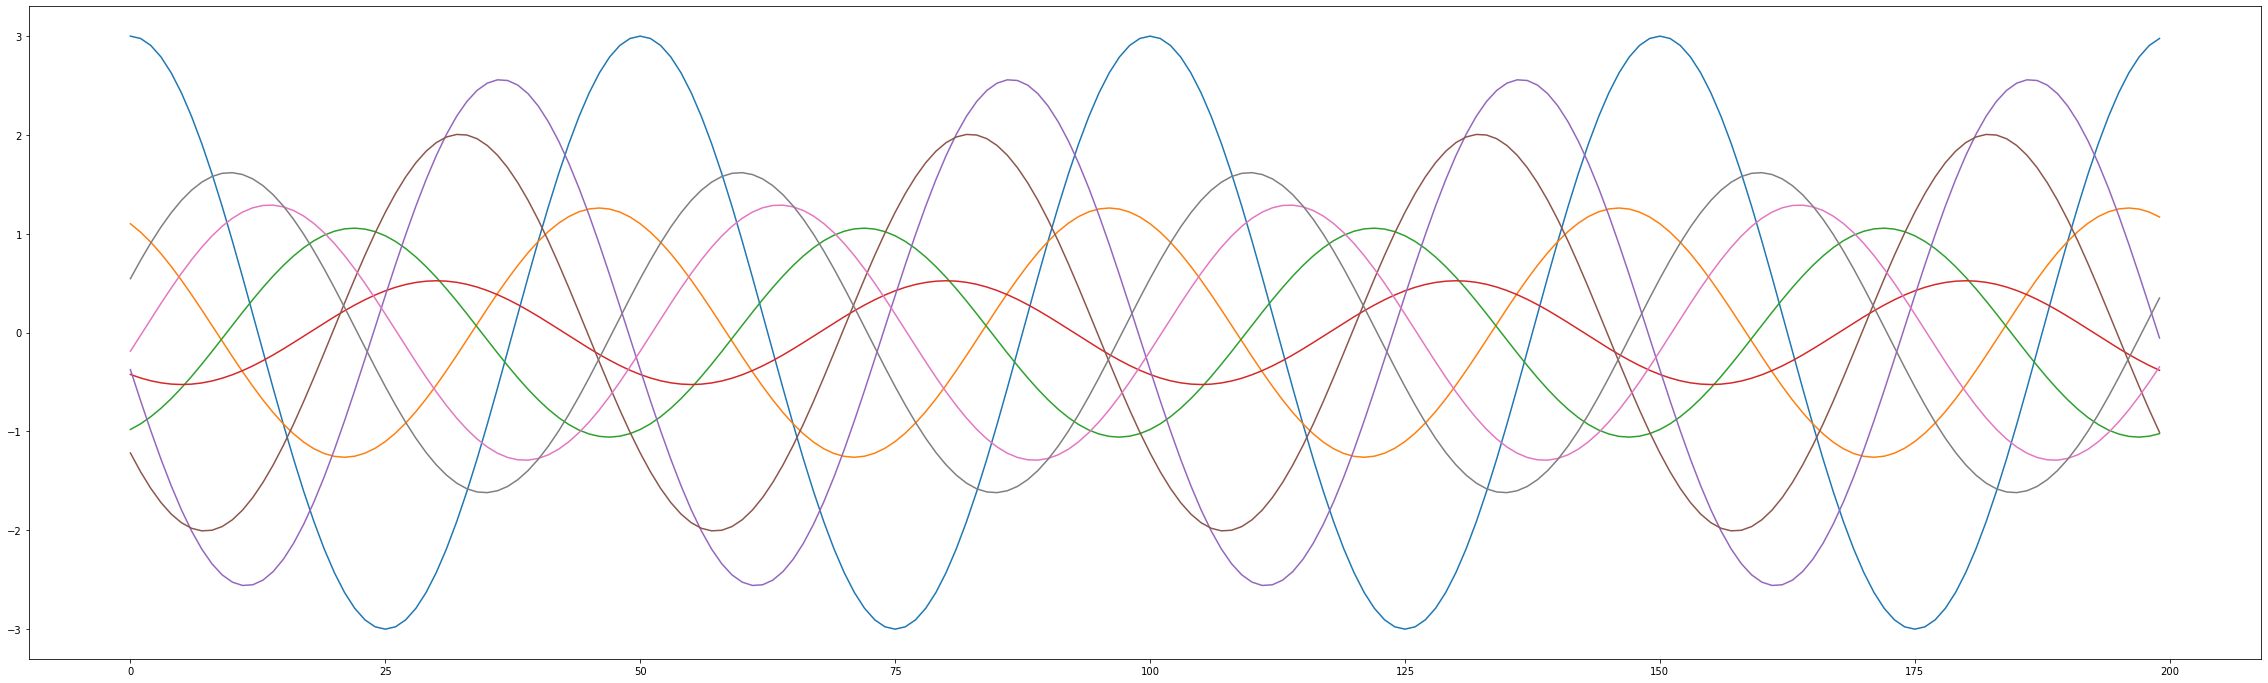

In [22]:
theta_deg = np.array([-20, 35, 10])
theta = np.deg2rad(theta_deg)


M = 8 # element of array
K = len(theta_deg) 

d = 0.5
lam = 1

#=================transmit signal====================
sample_rate = 1e6
N = 10000 # number of samples to simulate

# Create a tone to act as the transmitter signal
t = np.arange(N)/sample_rate # time vector
f_t = 0.02e6
tx = np.exp(2j * np.pi * f_t * t)

S = np.zeros((K, N), dtype=complex)

for k in range(K):
    S[k, :] = tx
#=====================================================


#==================Steering matrix===================
A = np.zeros((M, K), dtype=complex)

for k in range(K):
    for m in range(M):
        A[m, k] = np.exp(1j * 2*np.pi * (d/lam) * m * np.sin(theta[k]))
#=====================================================

print("shape of A: ", A.shape)
print("shape of S: ", S.shape)

X = A @ S   # (8 x 10000) # Simulate the received signal X through a matrix multiply
print("shape of received signal:", X.shape) # 24x10000.  X is now going to be a 2D array, 1D is time and 1D is the spatial dimension

"""
n = np.random.randn(M, N) + 1j*np.random.randn(M, N)
X = X + 0.1*n # X and n are both 3x10000
"""

plt.figure(figsize=(40, 12))
plt.plot(np.asarray(X[0,:]).squeeze().real[0:200]) # the asarray and squeeze are just annoyances we have to do because we came from a matrix
plt.plot(np.asarray(X[1,:]).squeeze().real[0:200])
plt.plot(np.asarray(X[2,:]).squeeze().real[0:200])
plt.plot(np.asarray(X[3,:]).squeeze().real[0:200])
plt.plot(np.asarray(X[4,:]).squeeze().real[0:200])
plt.plot(np.asarray(X[5,:]).squeeze().real[0:200])
plt.plot(np.asarray(X[6,:]).squeeze().real[0:200])
plt.plot(np.asarray(X[7,:]).squeeze().real[0:200])

plt.show()



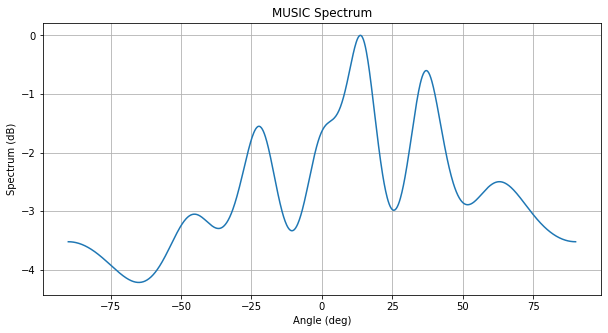

In [23]:
# Covariance matrix
R = X @ X.conj().T / N

# Eigen-decomposition
eigvals, eigvecs = np.linalg.eigh(R)

# Sort eigenvalues
idx = np.argsort(eigvals)[::-1]
eigvecs = eigvecs[:, idx]

# Noise subspace
En = eigvecs[:, K:]

# Scan angles
angles = np.linspace(-90, 90, 1000)
P_music = []

for ang in angles:
    a = np.exp(1j * np.pi * np.arange(M) * np.sin(np.deg2rad(ang)))
    a = a.reshape(-1,1)
    P = 1 / np.abs(a.conj().T @ En @ En.conj().T @ a)
    P_music.append(P[0,0])

P_music = np.array(P_music)

plt.figure(figsize=(10,5))
plt.plot(angles, 10*np.log10(P_music/np.max(P_music)))
plt.xlabel("Angle (deg)")
plt.ylabel("Spectrum (dB)")
plt.title("MUSIC Spectrum")
plt.grid()
plt.show()

Estimated DOA: [-22.43243243  13.6036036   37.02702703]


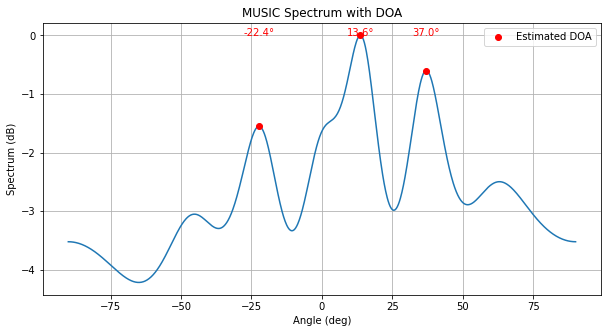

In [24]:
from scipy.signal import find_peaks

# find peak
peaks, _ = find_peaks(P_music)

peak_vals = P_music[peaks]
topk_idx = np.argsort(peak_vals)[-K:]
selected_peaks = peaks[topk_idx]

est_angles = angles[selected_peaks]

print("Estimated DOA:", np.sort(est_angles))

# plot
plt.figure(figsize=(10,5))
plt.plot(angles, 10*np.log10(P_music/np.max(P_music)))

# find peak
plt.plot(est_angles,
         10*np.log10(P_music[selected_peaks]/np.max(P_music)),
         'ro', label='Estimated DOA')

# print estimate angle
for ang in est_angles:
    plt.text(ang, 0, f"{ang:.1f}°", color='red', ha='center')

plt.xlabel("Angle (deg)")
plt.ylabel("Spectrum (dB)")
plt.title("MUSIC Spectrum with DOA")
plt.legend()
plt.grid()
plt.show()